In [31]:
import open3d as o3d
import os
import numpy as np
import h5py
from matplotlib import pyplot as plt
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt

# CHANGRABLE VARIABLES
dataset_name = 'ketchup_heinz_400ml_segmentation_date_20250526_time_174343_numPoints_64_maxObjects_5_numrientations_10.h5'


In [32]:
DATASET_DIR = os.path.join(os.getcwd(), dataset_name)
with h5py.File(DATASET_DIR, 'r') as f:
    # Read datasets
    seg_points = f["seg_points"][:]  
    seg_colors = f["seg_colors"][:]  
    seg_labels = f["seg_labels"][:]  
print(seg_points.shape)
print(seg_colors.shape)
print(seg_labels.shape)


(12000, 320, 3)
(12000, 320, 3)
(12000, 320, 2)


Random sample index: 5006


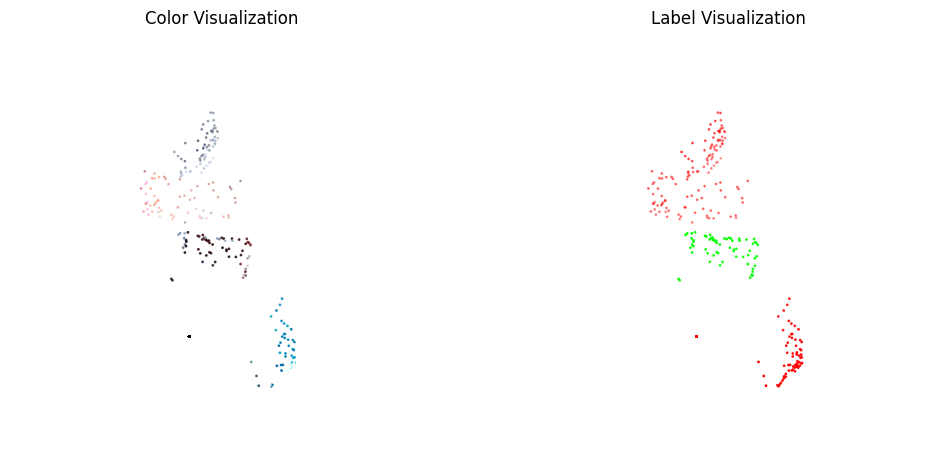

In [40]:
N = random.randint(0, seg_points.shape[0]-1)
print("Random sample index:", N)
points_sample = seg_points[N, :, :]
colors_sample = seg_colors[N, :, :]
labels_sample = np.where((seg_labels[N, :, :] == np.array([1, 0])).all(axis=1, keepdims=True), [0, 1, 0], [1, 0, 0])

fig = plt.figure(figsize=(12, 6))

# First subplot for color visualization
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
            c=colors_sample, s=1)
ax1.set_title("Color Visualization")
ax1.set_axis_off()

# Second subplot for label visualization
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
            c=labels_sample, s=1)
ax2.set_title("Label Visualization")
ax2.set_axis_off()

plt.show()



In [41]:
pcd_colors = o3d.geometry.PointCloud()
pcd_colors.points = o3d.utility.Vector3dVector(points_sample)
pcd_colors.colors = o3d.utility.Vector3dVector(colors_sample)
o3d.visualization.draw_geometries([pcd_colors], window_name="Color Visualization")

pcd_labels = o3d.geometry.PointCloud()
pcd_labels.points = o3d.utility.Vector3dVector(points_sample)
pcd_labels.colors = o3d.utility.Vector3dVector(labels_sample)
o3d.visualization.draw_geometries([pcd_labels], window_name="Label Visualization")

